# 04 — Walk-Forward Backtest (out-of-sample)

Notebook 03 was **in-sample**: the model had seen the whole history, including every crash. Here we do the honest test.

**Every year, starting in 2010:**
1. Train the HMM and estimate each regime's statistics using **only data up to Dec 31 of the previous year**
2. Optimize max-Sharpe weights for each regime (max 80% per asset)
3. During the year, estimate today's regime with the **forward filter**, which uses only data up to today
4. Hold a probability-weighted mix of the regime weights; trade at tomorrow's return, 5 bps cost on turnover

**Benchmarks** (same 2010–2026 period):
- **60/40**, **Equal weight**, **SPY** buy-and-hold
- **Static max-Sharpe**: same optimizer and yearly refits but *no regimes*. This isolates what the regime model itself adds.

All logic lives in `src/backtest.py`.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd

from src.config import REPORTS_DIR
from src.data import download_prices, compute_returns
from src.portfolio import static_weights, portfolio_returns, performance
from src.backtest import (
    walk_forward, walk_forward_static, annual_turnover, calendar_year_returns, period_returns,
)

REPORTS_DIR.mkdir(exist_ok=True)
COST_BPS = 5

## 1. Run the walk-forward
This fits the model 17 times (once per year), so it takes a few minutes.

In [2]:
prices = download_prices()
returns = compute_returns(prices)

regime_w, regime_probs, refit_log = walk_forward(returns, first_test_year=2010, mode="soft")
static_w = walk_forward_static(returns, first_test_year=2010)
refit_log

2010: trained on 1196 days
2011: trained on 1448 days
2012: trained on 1700 days
2013: trained on 1950 days
2014: trained on 2202 days
2015: trained on 2454 days
2016: trained on 2706 days
2017: trained on 2958 days
2018: trained on 3209 days
2019: trained on 3460 days
2020: trained on 3712 days
2021: trained on 3965 days
2022: trained on 4217 days
2023: trained on 4468 days
2024: trained on 4718 days
2025: trained on 4970 days
2026: trained on 5220 days


,train_days,log_likelihood,w_stress_SPY,w_stress_TLT,w_stress_GLD
test_year,,,,,
2010,1196,-3494.1,0.00,0.20,0.80
2011,1448,-4560.4,0.00,0.25,0.75
2012,1700,-5601.4,0.00,0.47,0.53
2013,1950,-6667.4,0.20,0.48,0.31
2014,2202,-7482.8,0.14,0.53,0.34
2015,2454,-8586.6,0.13,0.59,0.29
2016,2706,-9621.9,0.21,0.53,0.26
2017,2958,-10651.4,0.21,0.46,0.34
2018,3209,-11640.7,0.17,0.46,0.37


## 2. Build all strategies on the same dates

In [3]:
idx = regime_w.index
strategies = {
    "SPY": static_weights(idx, {"SPY": 1, "TLT": 0, "GLD": 0}),
    "60/40": static_weights(idx),
    "Equal weight": static_weights(idx, {"SPY": 1/3, "TLT": 1/3, "GLD": 1/3}),
    "Static max-Sharpe": static_w.loc[idx],
    "Regime max-Sharpe": regime_w,
}
port_rets = pd.DataFrame({n: portfolio_returns(returns, w, cost_bps=COST_BPS) for n, w in strategies.items()})

results = pd.DataFrame({n: performance(port_rets[n], n) for n in port_rets}).T
results["turnover_per_year"] = [annual_turnover(w) for w in strategies.values()]
results.round(3)

,ann_return,ann_vol,sharpe,max_drawdown,final_wealth,turnover_per_year
SPY,0.142,0.171,0.831,-0.337,9.069,0.000
60/40,0.102,0.103,0.992,-0.272,5.028,0.000
Equal weight,0.091,0.094,0.974,-0.227,4.279,0.000
Static max-Sharpe,0.087,0.098,0.889,-0.263,3.984,0.074
Regime max-Sharpe,0.100,0.101,0.994,-0.269,4.885,3.418


## 3. Growth of $1 and drawdowns

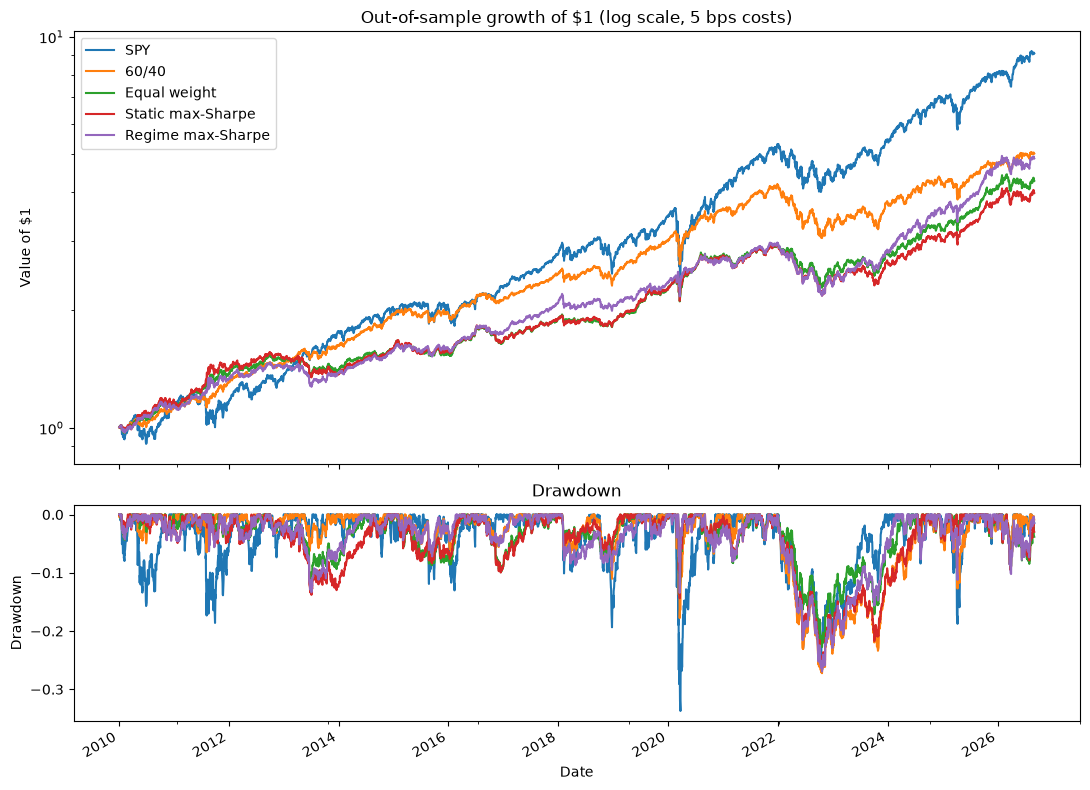

In [4]:
wealth = (1 + port_rets).cumprod()
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
wealth.plot(ax=axes[0], logy=True, title="Out-of-sample growth of $1 (log scale, 5 bps costs)")
axes[0].set_ylabel("Value of $1")
(wealth / wealth.cummax() - 1).plot(ax=axes[1], legend=False, title="Drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "backtest_growth_drawdown.png", dpi=150)
plt.show()

## 4. What did the strategy actually hold?

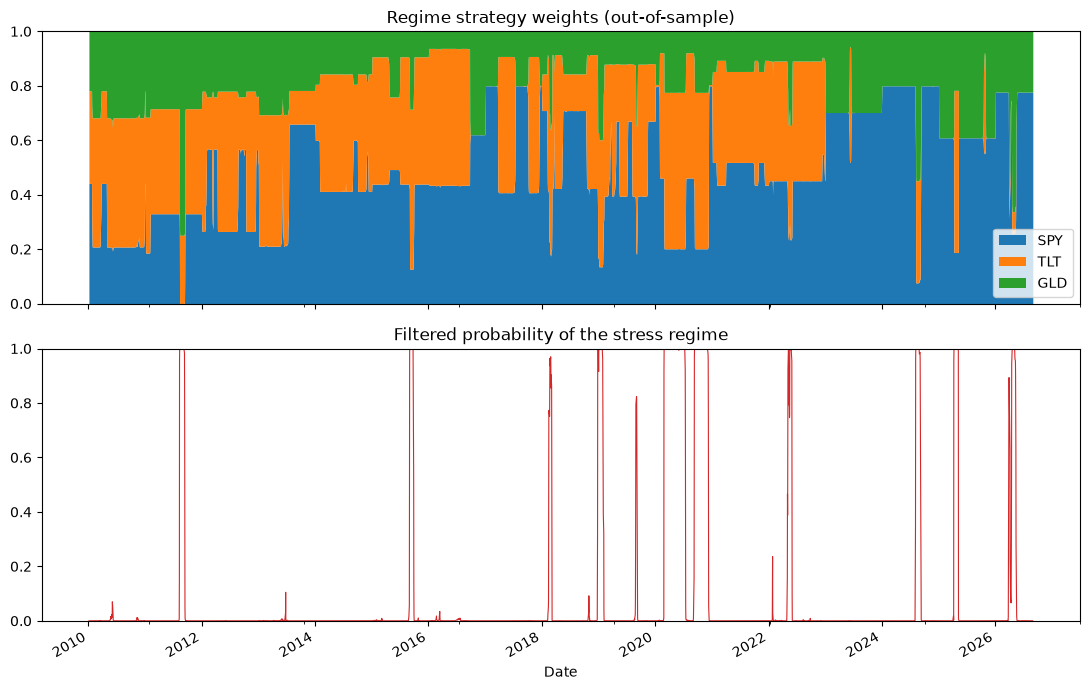

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
regime_w.plot.area(ax=axes[0], color=["tab:blue", "tab:orange", "tab:green"], linewidth=0)
axes[0].set_title("Regime strategy weights (out-of-sample)")
axes[0].set_ylim(0, 1)
regime_probs[regime_probs.columns[-1]].plot(ax=axes[1], color="tab:red", linewidth=0.8)
axes[1].set_title("Filtered probability of the stress regime")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "backtest_weights.png", dpi=150)
plt.show()

## 5. Year by year and during crises

In [6]:
yearly = calendar_year_returns(port_rets)
yearly.round(3)

,SPY,60/40,Equal weight,Static max-Sharpe,Regime max-Sharpe
Date,,,,,
2010,0.131,0.127,0.172,0.182,0.145
2011,0.019,0.159,0.165,0.191,0.161
2012,0.160,0.111,0.090,0.074,0.073
2013,0.323,0.122,-0.056,-0.096,-0.030
2014,0.135,0.193,0.128,0.162,0.136
2015,0.012,0.008,-0.031,-0.017,0.013
2016,0.120,0.081,0.077,0.066,0.095
2017,0.217,0.168,0.147,0.143,0.195
2018,-0.046,-0.029,-0.022,-0.022,-0.016


In [7]:
crises = {
    "COVID crash (Feb-Mar 2020)": ("2020-02-19", "2020-03-23"),
    "2022 rate hikes":            ("2022-01-03", "2022-10-12"),
}
crisis_table = period_returns(port_rets, crises)
crisis_table.round(3)

,SPY,60/40,Equal weight,Static max-Sharpe,Regime max-Sharpe
COVID crash (Feb-Mar 2020),-0.334,-0.160,-0.085,-0.075,-0.040
2022 rate hikes,-0.241,-0.263,-0.212,-0.245,-0.255


## 6. Sensitivity to trading costs
If the edge disappears with realistic costs, it is not real.

In [8]:
cost_check = {}
for bps in [0, 5, 20]:
    cost_check[f"{bps} bps"] = {
        n: performance(portfolio_returns(returns, strategies[n], cost_bps=bps))["sharpe"]
        for n in ["Equal weight", "Static max-Sharpe", "Regime max-Sharpe"]
    }
cost_check = pd.DataFrame(cost_check)
cost_check.round(3)

,0 bps,5 bps,20 bps
Equal weight,0.974,0.974,0.974
Static max-Sharpe,0.889,0.889,0.887
Regime max-Sharpe,1.012,0.994,0.938


In [9]:
results.round(4).to_csv(REPORTS_DIR / "backtest_summary.csv")
yearly.round(4).to_csv(REPORTS_DIR / "backtest_yearly.csv")
print("Saved to reports/")

Saved to reports/


## 7. Key numbers (text summary)

In [10]:
print("Test period:", idx[0].date(), "to", idx[-1].date())
print("\nOut-of-sample performance (5 bps costs):")
print(results.round(3).to_string())
print("\nCalendar-year returns:")
print(yearly.round(3).to_string())
print("\nCrisis periods:")
print(crisis_table.round(3).to_string())
print("\nSharpe vs trading costs:")
print(cost_check.round(3).to_string())
print("\nStress-regime weights at each refit:")
print(refit_log[[c for c in refit_log.columns if c.startswith("w_stress")]].to_string())

Test period: 2010-01-04 to 2026-08-31

Out-of-sample performance (5 bps costs):
                   ann_return  ann_vol  sharpe  max_drawdown  final_wealth  turnover_per_year
SPY                     0.142    0.171   0.831        -0.337         9.069              0.000
60/40                   0.102    0.103   0.992        -0.272         5.028              0.000
Equal weight            0.091    0.094   0.974        -0.227         4.279              0.000
Static max-Sharpe       0.087    0.098   0.889        -0.263         3.984              0.074
Regime max-Sharpe       0.100    0.101   0.994        -0.269         4.885              3.418

Calendar-year returns:
        SPY  60/40  Equal weight  Static max-Sharpe  Regime max-Sharpe
Date                                                                  
2010  0.131  0.127         0.172              0.182              0.145
2011  0.019  0.159         0.165              0.191              0.161
2012  0.160  0.111         0.090              0.

## Takeaways

**1. The in-sample edge mostly disappears.** Sharpe 1.07 in-sample (notebook 03) vs **0.99 out-of-sample**, tied with 60/40 (0.99) and barely above equal weight (0.97).

**2. Regimes do help the optimizer:** the same max-Sharpe optimizer without regimes scores 0.89, so regimes add ~+0.10 Sharpe.

**3. Protects in growth shocks, not rate shocks.** COVID crash: −4.0% (60/40 −16.0%, SPY −33.4%). 2022: −25.5%, worse than equal weight (−21.2%), because the stress weights still held ~42% bonds, learned from crises where bonds hedged.

**4. Fragile to costs.** 3.4× turnover per year; at 20 bps the Sharpe falls to 0.94, below equal weight.

**Conclusion:** the HMM protects against the kinds of stress it has already seen, but cannot anticipate a new kind. After costs, it does not beat simple diversification.